## Bank Default Loan Analysis

### STEP1: Libraries Import

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Step2: Dataset load

In [26]:
df = pd.read_excel(r"C:\Users\Sarvadnya\Downloads\bank_loan_default_data (2).xlsx")

In [28]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Term,Default_Status
0,59,31032.0,111929.0,567.0,Self-Employed,24,1
1,49,17198.0,NaN,718.0,Salaried,36,0
2,35,75500.0,278590.0,534.0,Self-Employed,12,0
3,63,NaN,411008.0,610.0,Self-Employed,24,0
4,28,35079.0,193401.0,NaN,Self-Employed,60,0
...,...,...,...,...,...,...,...
1245,22,114713.0,162020.0,NaN,Salaried,12,0
1246,21,53709.0,94936.0,664.0,Self-Employed,12,1
1247,28,46860.0,201426.0,328.0,Salaried,36,1
1248,39,28859.0,137468.0,426.0,Self-Employed,12,0


In [30]:
df.head()

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Term,Default_Status
0,59,31032.0,111929.0,567.0,Self-Employed,24,1
1,49,17198.0,NaN,718.0,Salaried,36,0
2,35,75500.0,278590.0,534.0,Self-Employed,12,0
3,63,NaN,411008.0,610.0,Self-Employed,24,0
4,28,35079.0,193401.0,NaN,Self-Employed,60,0


In [32]:
df.tail()

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Term,Default_Status
1245,22,114713.0,162020.0,NaN,Salaried,12,0
1246,21,53709.0,94936.0,664.0,Self-Employed,12,1
1247,28,46860.0,201426.0,328.0,Salaried,36,1
1248,39,28859.0,137468.0,426.0,Self-Employed,12,0
1249,22,90388.0,146019.0,667.0,Salaried,36,0


In [34]:
df.shape    #row and column

(1250, 7)

In [36]:
df.info()   #data types and null values 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              1250 non-null   int64  
 1   Income           1152 non-null   float64
 2   Loan_Amount      1152 non-null   float64
 3   Credit_Score     1150 non-null   float64
 4   Employment_Type  1250 non-null   object 
 5   Loan_Term        1250 non-null   int64  
 6   Default_Status   1250 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 68.5+ KB


In [38]:
df.describe()   #statistical summary

,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
count,1250.00000,1152.000000,1152.000000,1150.000000,1250.000000,1250.000000
mean,42.39280,67672.110243,269798.613715,578.294783,33.120000,0.298400
std,12.59666,29851.213434,130629.782393,160.633729,17.419792,0.457739
min,21.00000,15060.000000,50781.000000,300.000000,12.000000,0.000000
25%,31.00000,42423.000000,159886.000000,436.000000,24.000000,0.000000
50%,43.00000,66903.000000,259120.500000,581.000000,36.000000,0.000000
75%,53.00000,93461.250000,380944.750000,719.750000,36.000000,1.000000
max,64.00000,119956.000000,499916.000000,849.000000,60.000000,1.000000


### STEP 3: Missing values Analysis

In [41]:
df.isnull().sum()    #sum

Age                  0
Income              98
Loan_Amount         98
Credit_Score       100
Employment_Type      0
Loan_Term            0
Default_Status       0
dtype: int64

In [43]:
df["Income"].fillna(df["Income"].mean(), inplace=True)
df["Loan_Amount"].fillna(df["Loan_Amount"].median(), inplace=True)
df["Credit_Score"].fillna(df["Credit_Score"].mean(), inplace=True)                                 

C:\Users\Sarvadnya\AppData\Local\Temp\ipykernel_17216\3431986499.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(df["Income"].mean(), inplace=True)
C:\Users\Sarvadnya\AppData\Local\Temp\ipykernel_17216\3431986499.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [45]:
df

,Age,Income,Loan_Amount,Credit_Score,Employment_Type,Loan_Term,Default_Status
0,59,31032.000000,111929.0,567.000000,Self-Employed,24,1
1,49,17198.000000,259120.5,718.000000,Salaried,36,0
2,35,75500.000000,278590.0,534.000000,Self-Employed,12,0
3,63,67672.110243,411008.0,610.000000,Self-Employed,24,0
4,28,35079.000000,193401.0,578.294783,Self-Employed,60,0
...,...,...,...,...,...,...,...
1245,22,114713.000000,162020.0,578.294783,Salaried,12,0
1246,21,53709.000000,94936.0,664.000000,Self-Employed,12,1
1247,28,46860.000000,201426.0,328.000000,Salaried,36,1
1248,39,28859.000000,137468.0,426.000000,Self-Employed,12,0


In [47]:
df.isnull().sum()

Age                0
Income             0
Loan_Amount        0
Credit_Score       0
Employment_Type    0
Loan_Term          0
Default_Status     0
dtype: int64

### STEP 4: Duplicate Values Remove

In [50]:
df.duplicated().sum()

50

In [52]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of       Age         Income  Loan_Amount  Credit_Score Employment_Type  \
0      59   31032.000000     111929.0    567.000000   Self-Employed   
1      49   17198.000000     259120.5    718.000000        Salaried   
2      35   75500.000000     278590.0    534.000000   Self-Employed   
3      63   67672.110243     411008.0    610.000000   Self-Employed   
4      28   35079.000000     193401.0    578.294783   Self-Employed   
...   ...            ...          ...           ...             ...   
1245   22  114713.000000     162020.0    578.294783        Salaried   
1246   21   53709.000000      94936.0    664.000000   Self-Employed   
1247   28   46860.000000     201426.0    328.000000        Salaried   
1248   39   28859.000000     137468.0    426.000000   Self-Employed   
1249   22   90388.000000     146019.0    667.000000        Salaried   

      Loan_Term  Default_Status  
0            24               1  
1            36               0  
2 

### STEP 6: Data Type Conversion

In [55]:
df['Default_Status'] #column ko show krna 
df['Default_Status'].astype(int) #column ke data ko int(no.)me convert krna

0       1
1       0
2       0
3       0
4       0
       ..
1245    0
1246    1
1247    1
1248    0
1249    0
Name: Default_Status, Length: 1250, dtype: int32

### EXPLORATORY DATA ANALYSIS (EDA)

### 1. Loan Default Distribution

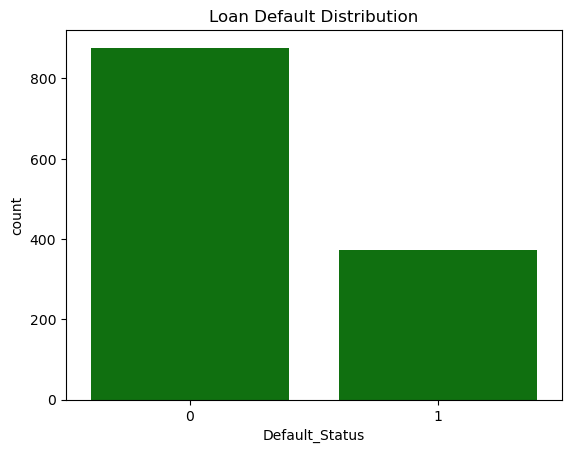

In [31]:
sns.countplot(x='Default_Status', data=df,
color='green')
plt.title("Loan Default Distribution")
plt.show()

In [ ]:
Insight : Most customers are non-defaulters, indicating a lower loan default rate in the dataset.

### 2. Age vs Default

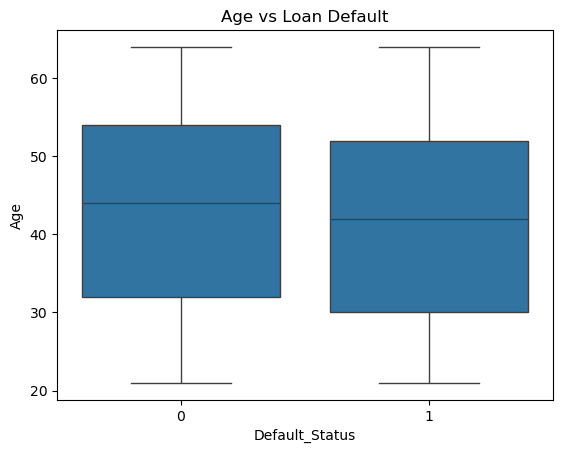

In [73]:
sns.boxplot(x='Default_Status', y='Age', data=df)      # identify media,age,minimum & max ,
plt.title("Age vs Loan Default")
plt.show()

In [ ]:
Insight :The boxplot shows the distribution of age across defaulters and non-defaulters.
Age has a limited/moderate impact on loan default as the age ranges overlap.

### 3. Income vs Default

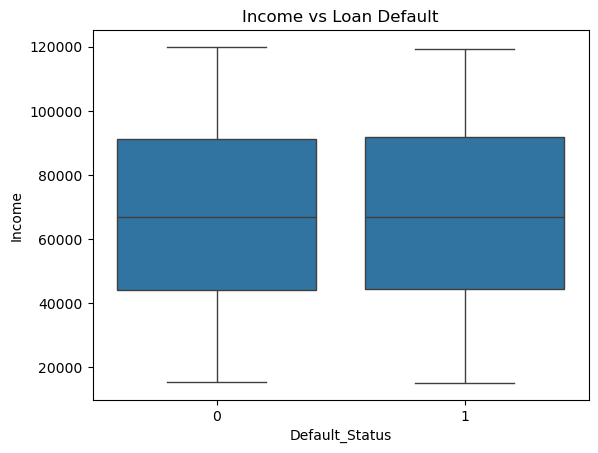

In [78]:
sns.boxplot(x='Default_Status', y='Income', data=df)
plt.title("Income vs Loan Default")
plt.show()

In [ ]:
The box plot shows that customers with lower income are more likely to default on loans, while higher income customers tend to repay on time.

### 4. Loan Amount Analysis

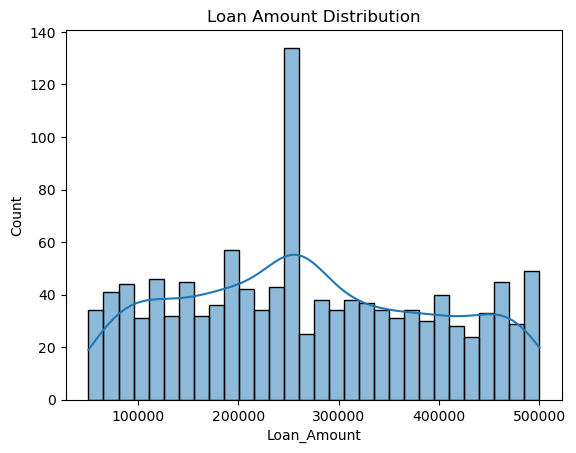

In [82]:
sns.histplot(df['Loan_Amount'], bins=30, kde=True)   #histogram= numerical data distribution,data range high,low
plt.title("Loan Amount Distribution")
plt.show()

In [ ]:
The histogram shows the distribution of loan amounts. Most customers take loans in the mid-range,
while very few customers opt for extremely high or low loan amounts.

### 5. Credit Score vs Default

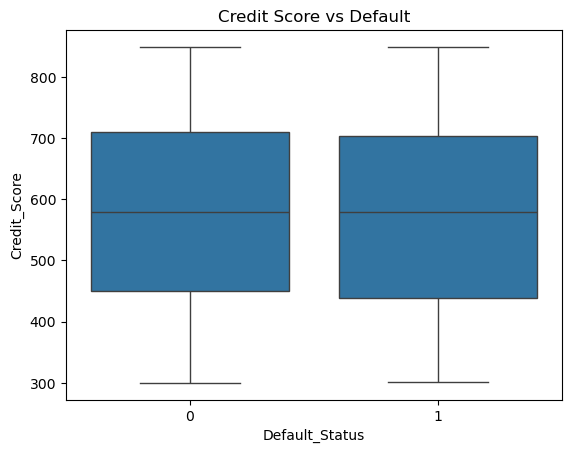

In [86]:
sns.boxplot(x='Default_Status', y='Credit_Score', data=df)
plt.title("Credit Score vs Default")
plt.show()

In [ ]:
The box plot shows that customers with lower credit scores are more likely to default,
while higher credit scores are associated with timely loan repayment.

In [ ]:
#Low credit score = HIGH DEFAULT RISK

### 6. Employment Type vs Default

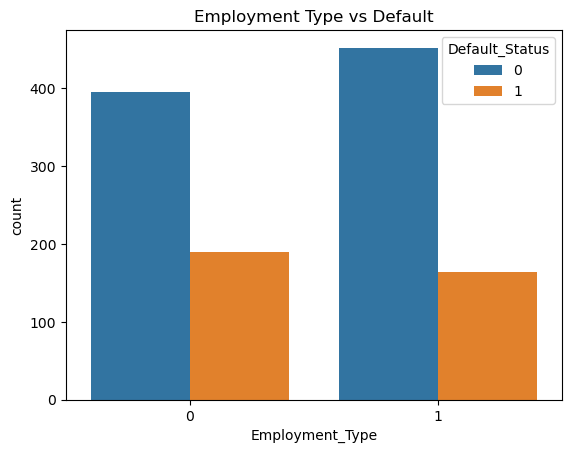

In [90]:
sns.countplot(x='Employment_Type', hue='Default_Status', data=df)
plt.title("Employment Type vs Default")
plt.show()

In [ ]:
The count plot shows that salaried customers have a lower default rate,
while self-employed customers are more likely to default due to income instability.

In [ ]:
#Self-employed applicants default slightly more.

### CONCLUSION

In [ ]:
This analysis helps banks identify high-risk customers and take
preventive actions to reduce loan defaults using data-driven insights.